# Smart Waste Classification System

# Notebook 04 — Data Preprocessing

**Author:** Syed Soban Mudassar

---

## Purpose

This notebook prepares the TrashNet dataset for machine learning.

The preprocessing stage converts the raw dataset into a format suitable for
deep learning by creating reproducible dataset splits and defining image
transformations.

Proper preprocessing improves model performance, reproducibility, and
evaluation reliability.

In [1]:
from pathlib import Path
import random
import shutil

import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

## Why These Libraries?

- `Path` provides platform-independent file handling.
- `random` is used to shuffle images before splitting.
- `shutil` copies files into train, validation, and test folders.
- `torchvision.transforms` performs preprocessing.
- `matplotlib` visualizes the results.
- `Pillow` opens image files.

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent

raw_dataset = project_root / "data" / "raw" / "trashnet"

processed_dataset = project_root / "data" / "processed"

train_path = processed_dataset / "train"
val_path = processed_dataset / "validation"
test_path = processed_dataset / "test"

print("Raw dataset:", raw_dataset)
print("Processed dataset:", processed_dataset)

Raw dataset: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\raw\trashnet
Processed dataset: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed


#  Why Split the Dataset?

Machine learning models must be evaluated using images that were not used
during training.

The dataset is divided into three parts.

## Training Set

Used to learn patterns.

## Validation Set

Used during development for tuning model parameters.

## Test Set

Used only once after training to measure final model performance.

Using separate datasets helps prevent overfitting and provides a fair estimate
of model accuracy.

In [4]:
classes = sorted(
    folder.name
    for folder in raw_dataset.iterdir()
    if folder.is_dir()
)

print("Classes found:")
print(classes)

Classes found:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
for split in ["train", "validation", "test"]:
    split_path = processed_dataset / split

    split_path.mkdir(parents=True, exist_ok=True)

    for class_name in classes:
        (split_path / class_name).mkdir(parents=True, exist_ok=True)

print("Processed dataset folders created successfully.")

Processed dataset folders created successfully.


#  Dataset Split Ratios

The dataset will be divided as follows:

- 70% Training
- 15% Validation
- 15% Test

These ratios provide enough training data while preserving separate datasets
for model tuning and final evaluation.

In [6]:
random.seed(42)

split_summary = []

for class_name in classes:

    source = raw_dataset / class_name

    images = list(source.glob("*.jpg"))

    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for image in train_images:
        shutil.copy(image, train_path / class_name / image.name)

    for image in val_images:
        shutil.copy(image, val_path / class_name / image.name)

    for image in test_images:
        shutil.copy(image, test_path / class_name / image.name)

    split_summary.append({
        "Class": class_name,
        "Total": total,
        "Train": len(train_images),
        "Validation": len(val_images),
        "Test": len(test_images)
    })

print("Dataset successfully split.")

Dataset successfully split.


In [7]:
import pandas as pd

split_df = pd.DataFrame(split_summary)

split_df

,Class,Total,Train,Validation,Test
0,cardboard,403,282,60,61
1,glass,501,350,75,76
2,metal,410,287,61,62
3,paper,594,415,89,90
4,plastic,482,337,72,73
5,trash,137,95,21,21


#  Image Transformations

Deep learning models require all images to have identical input dimensions.

The preprocessing pipeline performs:

- resizing
- tensor conversion
- normalization

Normalization improves numerical stability during training.

In [8]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

print(image_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


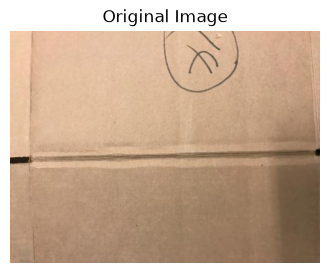

Tensor shape: torch.Size([3, 224, 224])


In [9]:
sample_image = next((raw_dataset / classes[0]).glob("*.jpg"))

image = Image.open(sample_image)

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

transformed = image_transform(image)

print("Tensor shape:", transformed.shape)

#  Observations

The preprocessing pipeline successfully:

- created reproducible dataset splits
- preserved the original dataset
- defined standard image transformations
- prepared images for PyTorch training

The original dataset remains unchanged because all processing occurs inside the
`processed` directory.

# Conclusion

The TrashNet dataset has now been fully prepared for machine learning.

The processed dataset includes separate training, validation, and test sets,
while image transformations have been defined for deep learning models.

The next stage of the project will focus on **data augmentation**, where the
training images will be artificially diversified to improve model
generalization.